# Heart Disease Prediction

## Feature Engineering and Model Development
In this notebook, we perform feature engineering, train multiple machine learning models, evaluate their performance using various metrics, and select the best-performing model for deployment.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [5]:
df = pd.read_csv("../data/processed/heart_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [6]:
print(df.shape)

df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [8]:
X = df.drop("target", axis=1)

y = df["target"]

print(X.shape)

print(y.shape)

(303, 13)
(303,)


In [9]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(242, 13)
(61, 13)


In [11]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("target", numeric_transformer, numerical_features)
    ],
    remainder="passthrough"
)

In [12]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('target', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
lr_pred = logistic_pipeline.predict(X_test)

lr_prob = logistic_pipeline.predict_proba(X_test)[:,1]

In [14]:
print("Accuracy :", accuracy_score(y_test, lr_pred))

print("Precision :", precision_score(y_test, lr_pred))

print("Recall :", recall_score(y_test, lr_pred))

print("F1 Score :", f1_score(y_test, lr_pred))

print("ROC-AUC :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.8688524590163934
Precision : 0.8125
Recall : 0.9285714285714286
F1 Score : 0.8666666666666667
ROC-AUC : 0.9512987012987013


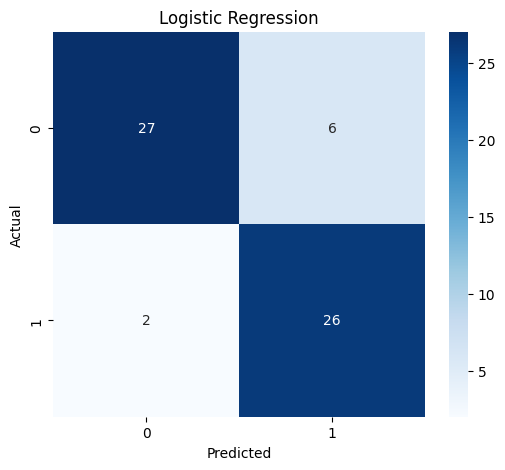

In [15]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

In [16]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [17]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('target', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

In [19]:
print("Accuracy :", accuracy_score(y_test, rf_pred))

print("Precision :", precision_score(y_test, rf_pred))

print("Recall :", recall_score(y_test, rf_pred))

print("F1 Score :", f1_score(y_test, rf_pred))

print("ROC-AUC :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.9016393442622951
Precision : 0.8666666666666667
Recall : 0.9285714285714286
F1 Score : 0.896551724137931
ROC-AUC : 0.9577922077922079


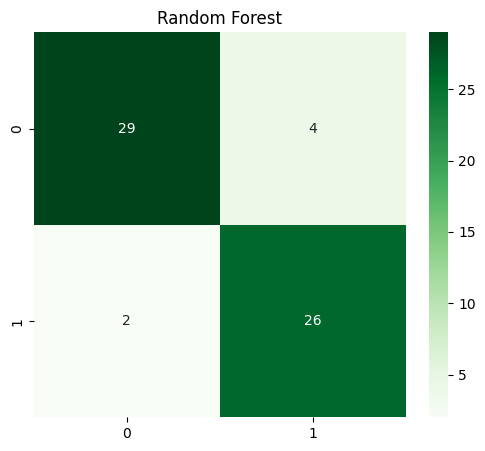

In [20]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest")

plt.show()

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

rf_cv = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy")

print(lr_cv)

print(lr_cv.mean())

print()

print("Random Forest CV Accuracy")

print(rf_cv)

print(rf_cv.mean())

Logistic Regression CV Accuracy
[0.91803279 0.81967213 0.81967213 0.78333333 0.85      ]
0.8381420765027322

Random Forest CV Accuracy
[0.8852459  0.80327869 0.85245902 0.8        0.85      ]
0.8381967213114754


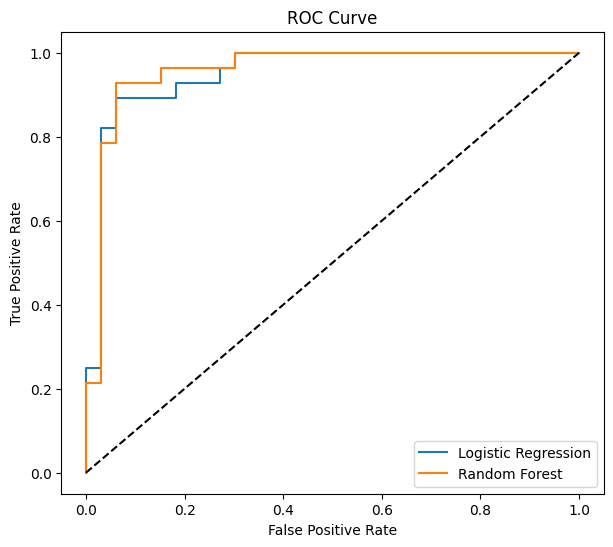

In [22]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
1,Random Forest,0.901639,0.866667,0.928571,0.896552,0.957792


### Model Selection

Two classification models were trained and evaluated:

1. Logistic Regression
2. Random Forest Classifier

Both models were assessed using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- 5-Fold Cross Validation

### Model Comparison

| Metric | Logistic Regression | Random Forest |
|---------|--------------------:|--------------:|
| Accuracy | 86.89% | **90.16%** |
| Precision | 81.25% | **86.67%** |
| Recall | **92.86%** | **92.86%** |
| F1-Score | 86.67% | **89.66%** |
| ROC-AUC | 0.9513 | **0.9578** |

### Selected Model

The **Random Forest Classifier** was selected as the final model because it achieved the highest overall predictive performance while maintaining excellent recall.

The selected model will be used in the next phases of the MLOps pipeline, including:

- Experiment Tracking (MLflow)
- Model Packaging
- API Development
- Docker Containerization
- CI/CD Pipeline
- Production Deployment

### Hyperparameter Configuration

The following models were trained using the specified configurations:

### Logistic Regression
- Solver: lbfgs (default)
- Regularization: L2
- Random State: 42

### Random Forest
- Number of Trees (n_estimators): 200
- Random State: 42

The Random Forest classifier was configured with 200 trees to improve prediction stability and reduce variance while maintaining reasonable training time. The chosen configuration provided the best balance between predictive performance and computational efficiency.

In [25]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the complete pipeline
joblib.dump(rf_pipeline, "models/heart_disease_rf_pipeline.pkl")

print("Random Forest pipeline saved successfully!")

Random Forest pipeline saved successfully!
